In [2]:
import json, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import (LeaveOneGroupOut, cross_val_predict,
                                      KFold, cross_val_score, GridSearchCV)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
import json, sys, glob, warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded successfully.")


def load_data(pa):
    trans = []
    data = json.load(open(pa, encoding="utf-8"))
    for ri, run in enumerate(data["runs"]):
        meta = run["metadata"]
        v = meta["v"]; cost = meta["product"]["cost"]; market = meta["product"]["market_price"]
        rounds = run["rounds"]
        m_init = rounds[0]["buyer_price"]; s_init = rounds[0]["supplier_price"]
        for i in range(1, len(rounds)):
            prev, curr = rounds[i-1], rounds[i]
            sp, mc, sc = prev["supplier_price"], curr["buyer_price"], curr["supplier_price"]
            if sp is None or sc is None:
                continue
            trans.append(dict(
                m_t=mc, s_prev=sp, s_t=sc, v=v, cost=cost, market=market,
                round_t=curr["round"], buyer_type=meta["buyer_type"]["name"],
                product=meta["product"]["name"], supplier_id=meta["supplier"]["id"],
                m_init=m_init, s_init=s_init if s_init else np.nan,
                m_prev=prev["buyer_price"], template_id=curr.get("template_id", -1),
                s_prev2=rounds[i-2]["supplier_price"] if i >= 2 else None,
                run_idx=ri,
                m_prev2=rounds[i-2]["buyer_price"] if i >= 2 else None,
                s_prev3=rounds[i-3]["supplier_price"] if i >= 3 else None,
                m_prev3=rounds[i-3]["buyer_price"] if i >= 3 else None
            ))
    return trans

all_data = []
for f in sorted(glob.glob(str("cooperative/random__*.json"))):
    if "transitions" in f: continue
    else:
        all_data.extend(load_data(f))

for f in sorted(glob.glob(str("cooperative/wild__*.json"))):
    if "transitions" in f: continue
    else:
        all_data.extend(load_data(f))

df = pd.DataFrame(all_data)
df['region'] = np.where(df['m_t'] < df['v'], 'Low',
                np.where(df['m_t'] > df['s_prev'], 'High', 'Negotiation'))
print(f"Dataset: {df.shape[0]} observations × {df.shape[1]} columns")
print(f"Runs: {df['run_idx'].nunique()}, samples per run: {df.groupby('run_idx').size().unique()}")
print(df.head(5))


Libraries loaded successfully.
Dataset: 1967 observations × 20 columns
Runs: 20, samples per run: [129 132 131 126  66  64]
    m_t  s_prev   s_t    v  cost  market  round_t buyer_type       product  \
0  0.85    1.00  0.95  0.7   0.3     1.5        2     random  Cola (330ml)   
1  1.31    0.95  1.31  0.7   0.3     1.5        3     random  Cola (330ml)   
2  0.78    1.31  0.90  0.7   0.3     1.5        4     random  Cola (330ml)   
3  1.01    0.90  1.01  0.7   0.3     1.5        5     random  Cola (330ml)   
4  1.45    1.01  1.45  0.7   0.3     1.5        6     random  Cola (330ml)   

  supplier_id  m_init  s_init  m_prev  template_id  s_prev2  run_idx  m_prev2  \
0          S1    0.58     1.0    0.58            6      NaN        0      NaN   
1          S1    0.58     1.0    0.85            5     1.00        0     0.58   
2          S1    0.58     1.0    1.31            4     0.95        0     0.85   
3          S1    0.58     1.0    0.78            1     1.31        0     1.31   
4 

# EDA

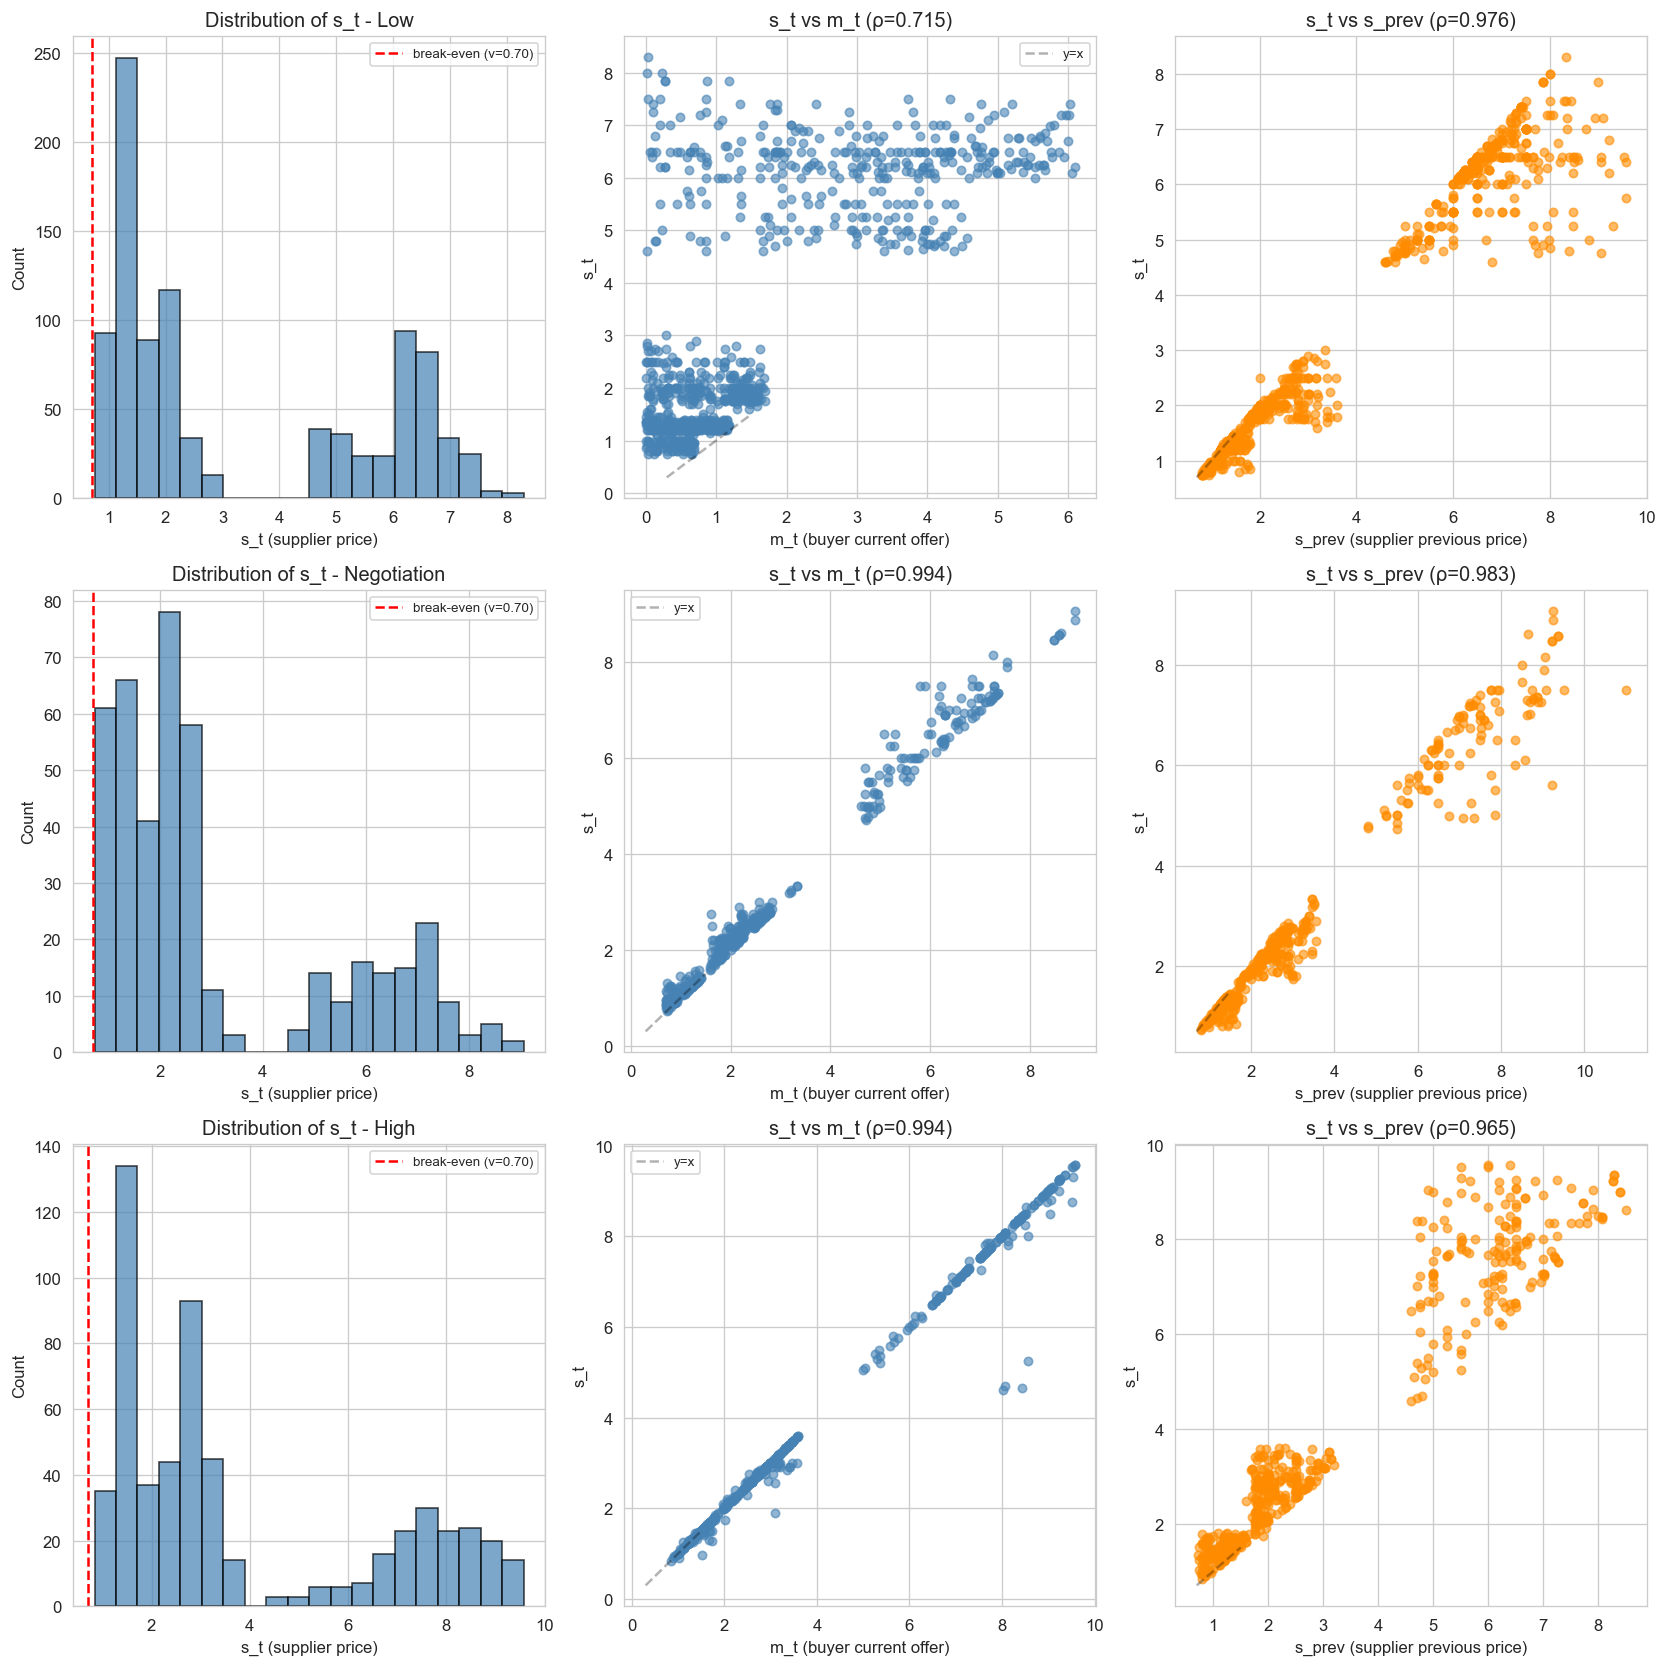

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(14, 14))

regions = ['Low', 'Negotiation', 'High']
for i in range(3):
    df_region = df[df['region'] == regions[i]]

    axes[i, 0].hist(df_region['s_t'], bins=20, edgecolor='k', alpha=0.7, color='steelblue')
    axes[i, 0].set_xlabel('s_t (supplier price)')
    axes[i, 0].set_ylabel('Count')
    axes[i, 0].set_title(f'Distribution of s_t - {regions[i]}')
    axes[i, 0].axvline(0.70, color='red', ls='--', label='break-even (v=0.70)')
    axes[i, 0].legend(fontsize=8)

    corr_mt_st = df_region[['m_t', 's_t']].corr().iloc[0, 1]
    axes[i, 1].scatter(df_region['m_t'], df_region['s_t'], alpha=0.6, s=25, c='steelblue')
    axes[i, 1].set_xlabel('m_t (buyer current offer)')
    axes[i, 1].set_ylabel('s_t')
    axes[i, 1].set_title(f's_t vs m_t (ρ={corr_mt_st:.3f})')
    axes[i, 1].plot([0.3, 1.5], [0.3, 1.5], 'k--', alpha=0.3, label='y=x')
    axes[i, 1].legend(fontsize=8)

    corr_sprev_st = df_region[['s_prev', 's_t']].corr().iloc[0, 1]
    axes[i, 2].scatter(df_region['s_prev'], df_region['s_t'], alpha=0.6, s=25, c='darkorange')
    axes[i, 2].set_xlabel('s_prev (supplier previous price)')
    axes[i, 2].set_ylabel('s_t')
    axes[i, 2].set_title(f's_t vs s_prev (ρ={corr_sprev_st:.3f})')
    axes[i, 2].plot([0.7, 1.5], [0.7, 1.5], 'k--', alpha=0.3)

plt.tight_layout()
plt.show()

## Part 1, fit the negotiation zone data


use fraction or use ordinary least square

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


baseline_features = ['m_t']
core_features = ['m_t', 's_prev', 'v']

more_features = ['m_t', 's_prev', 'round_t', 'm_prev', 'v']
lag2_more_features = more_features + ['s_prev2', 'm_prev2']

# Core dataset (no missing)
df_target = df[(df['region'] == "Negotiation") & (df['round_t'] <= 8)].copy()



# ------ Baseline dataset (only m_t) ------
x_baseline = df_target[baseline_features].values.copy()
y_baseline = df_target['s_t'].values.copy()
group_baseline = df_target['run_idx'].values.copy()


# ------ Core dataset (no missing) ------
x_core = df_target[core_features].values.copy()
y_core = df_target['s_t'].values.copy()
group_core = df_target['run_idx'].values.copy()

# ------ more features dataset (no missing) ------
x_more = df_target[more_features].values.copy()
y_more = df_target['s_t'].values.copy()
group_more = df_target['run_idx'].values.copy()

# ------ Lag-2 dataset (with more features) ------
df_lag2 = df_target.dropna(subset=['s_prev2', 'm_prev2']).copy()
x_lag2 = df_lag2[lag2_more_features].values.copy()
y_lag2 = df_lag2['s_t'].values.copy()
group_lag2 = df_lag2['run_idx'].values.copy()


# =========================================================
# 1. Evaluation helper
# =========================================================

def evaluate_linear_model(X, y, feature_names, model_name, test_size=0.3, random_state=42):
    """
    Fit OLS on a standard train/validation split and return metrics,
    fitted model, and predictions.
    """
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)

    result = {
        "model_name": model_name,
        "feature_names": feature_names,
        "X_train": X_train,
        "X_val": X_val,
        "y_train": y_train,
        "y_val": y_val,
        "y_pred_train": y_pred_train,
        "y_pred_val": y_pred_val,
        "r2_train": r2_score(y_train, y_pred_train),
        "r2_val": r2_score(y_val, y_pred_val),
        "rmse_train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "rmse_val": np.sqrt(mean_squared_error(y_val, y_pred_val)),
        "mae_train": mean_absolute_error(y_train, y_pred_train),
        "mae_val": mean_absolute_error(y_val, y_pred_val),
        "intercept": model.intercept_,
        "coef": model.coef_,
        "model_obj": model,
    }
    return result


# =========================================================
# 2. Run experiments across feature sets
# =========================================================

datasets = {
    "baseline": (x_baseline, y_baseline, baseline_features),
    "core": (x_core, y_core, core_features),
    "more": (x_more, y_more, more_features),
    "lag2": (x_lag2, y_lag2, lag2_more_features),
}

all_results = []

for dataset_name, (X, y, feats) in datasets.items():
    result = evaluate_linear_model(
        X=X,
        y=y,
        feature_names=feats,
        model_name=f"OLS_{dataset_name}",
        test_size=0.3,
        random_state=42
    )
    result["dataset_name"] = dataset_name
    all_results.append(result)


# =========================================================
# 3. Summary table
# =========================================================

results_table = pd.DataFrame([
    {
        "model": r["model_name"],
        "dataset": r["dataset_name"],
        "n_features": len(r["feature_names"]),
        "r2_train": r["r2_train"],
        "r2_val": r["r2_val"],
        "rmse_train": r["rmse_train"],
        "rmse_val": r["rmse_val"],
        "mae_train": r["mae_train"],
        "mae_val": r["mae_val"],
    }
    for r in all_results
])

print("\n===== Overall Results =====")
print(results_table.sort_values(by="r2_val", ascending=False).round(4))


# =========================================================
# 4. Learned parameter table
# =========================================================

param_rows = []
for r in all_results:
    param_rows.append({
        "model": r["model_name"],
        "feature": "INTERCEPT",
        "coefficient": r["intercept"]
    })
    for feat, coef in zip(r["feature_names"], r["coef"]):
        param_rows.append({
            "model": r["model_name"],
            "feature": feat,
            "coefficient": coef
        })

linear_params_table = pd.DataFrame(param_rows)

print("\n===== Learned Parameters for Linear Models =====")
print(linear_params_table.round(6))






===== Overall Results =====
          model   dataset  n_features  r2_train  r2_val  rmse_train  rmse_val  \
3      OLS_lag2      lag2           7    0.9934  0.9952      0.1748    0.1392   
2      OLS_more      more           5    0.9941  0.9931      0.1648    0.1912   
1      OLS_core      core           3    0.9936  0.9930      0.1719    0.1922   
0  OLS_baseline  baseline           1    0.9870  0.9863      0.2446    0.2695   

   mae_train  mae_val  
3     0.1098   0.0987  
2     0.1039   0.1107  
1     0.1053   0.1128  
0     0.1720   0.1894  

===== Learned Parameters for Linear Models =====
           model    feature  coefficient
0   OLS_baseline  INTERCEPT     0.131291
1   OLS_baseline        m_t     1.041151
2       OLS_core  INTERCEPT     0.066897
3       OLS_core        m_t     0.616106
4       OLS_core     s_prev     0.302085
5       OLS_core          v     0.106512
6       OLS_more  INTERCEPT     0.170352
7       OLS_more        m_t     0.617608
8       OLS_more     s_pre

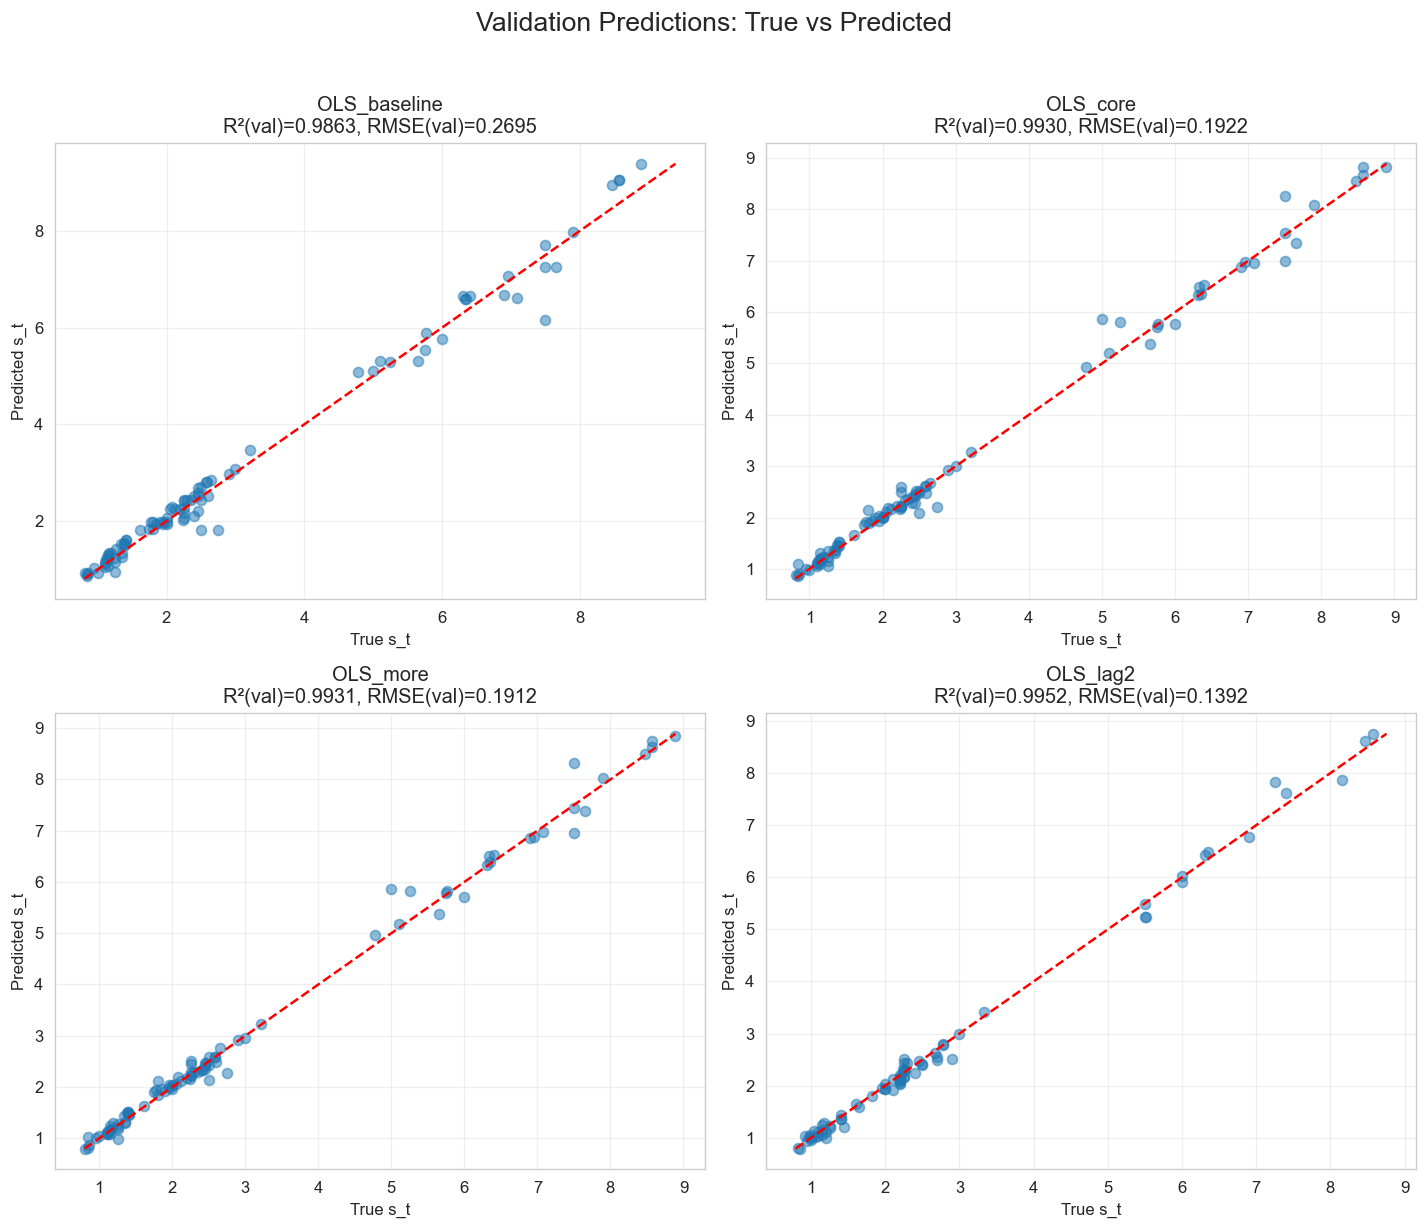

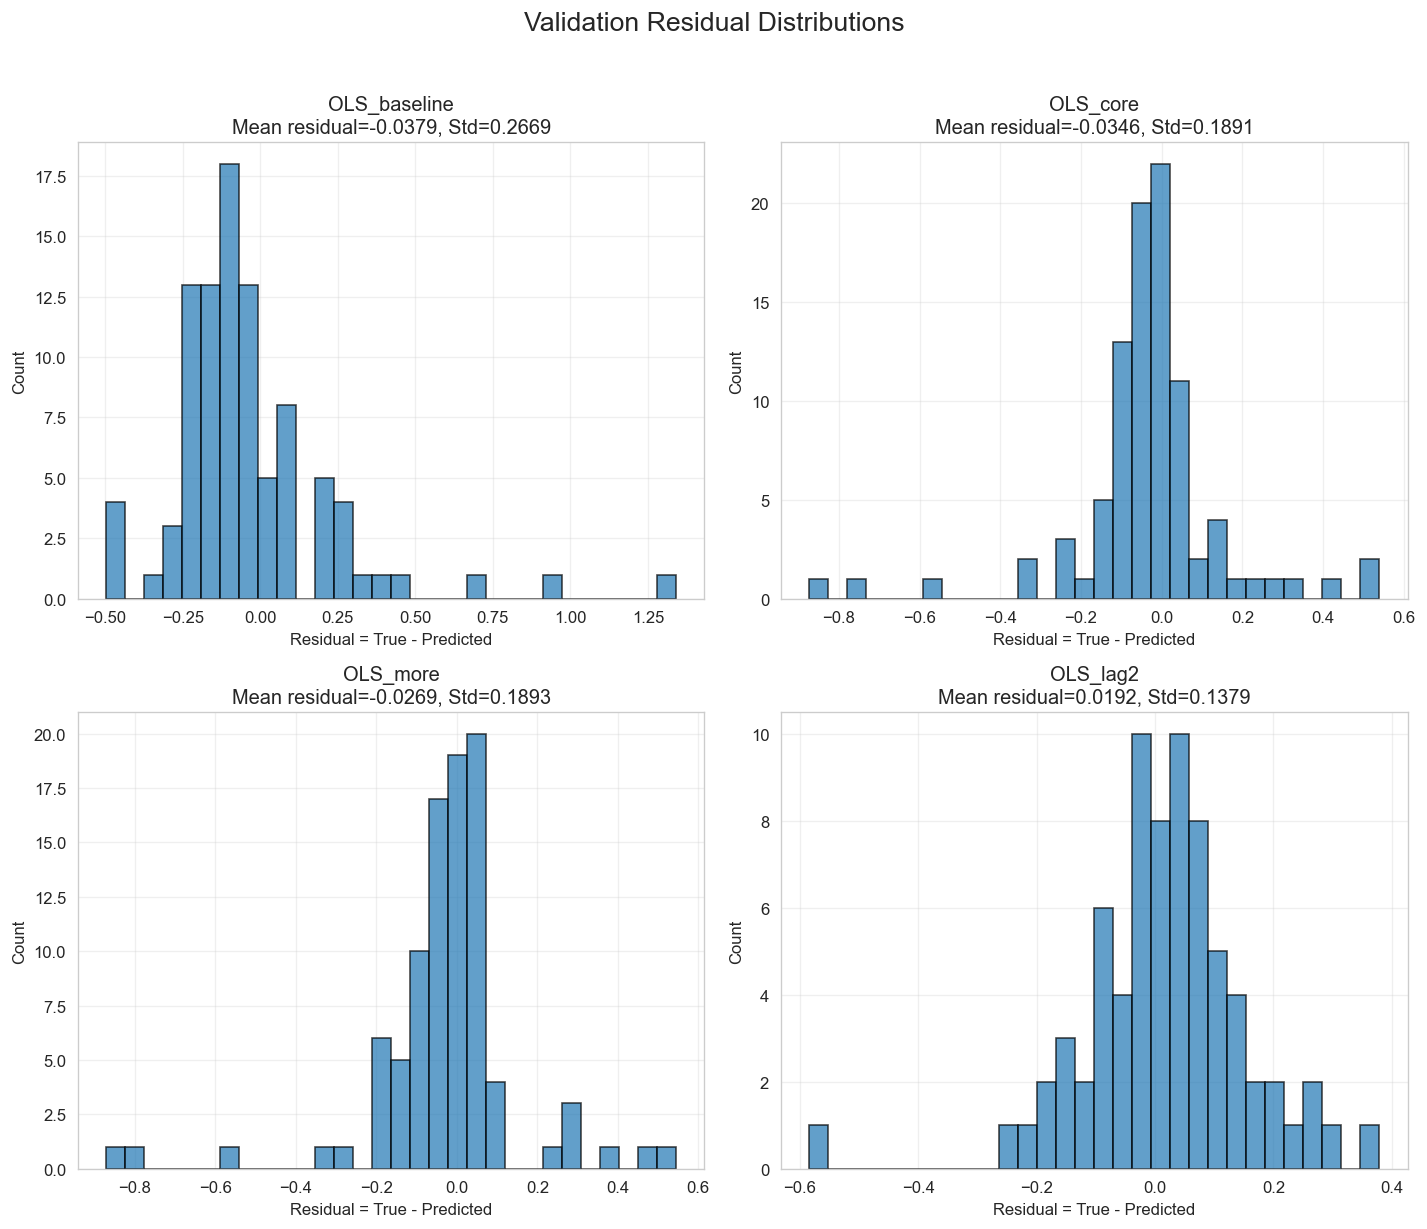

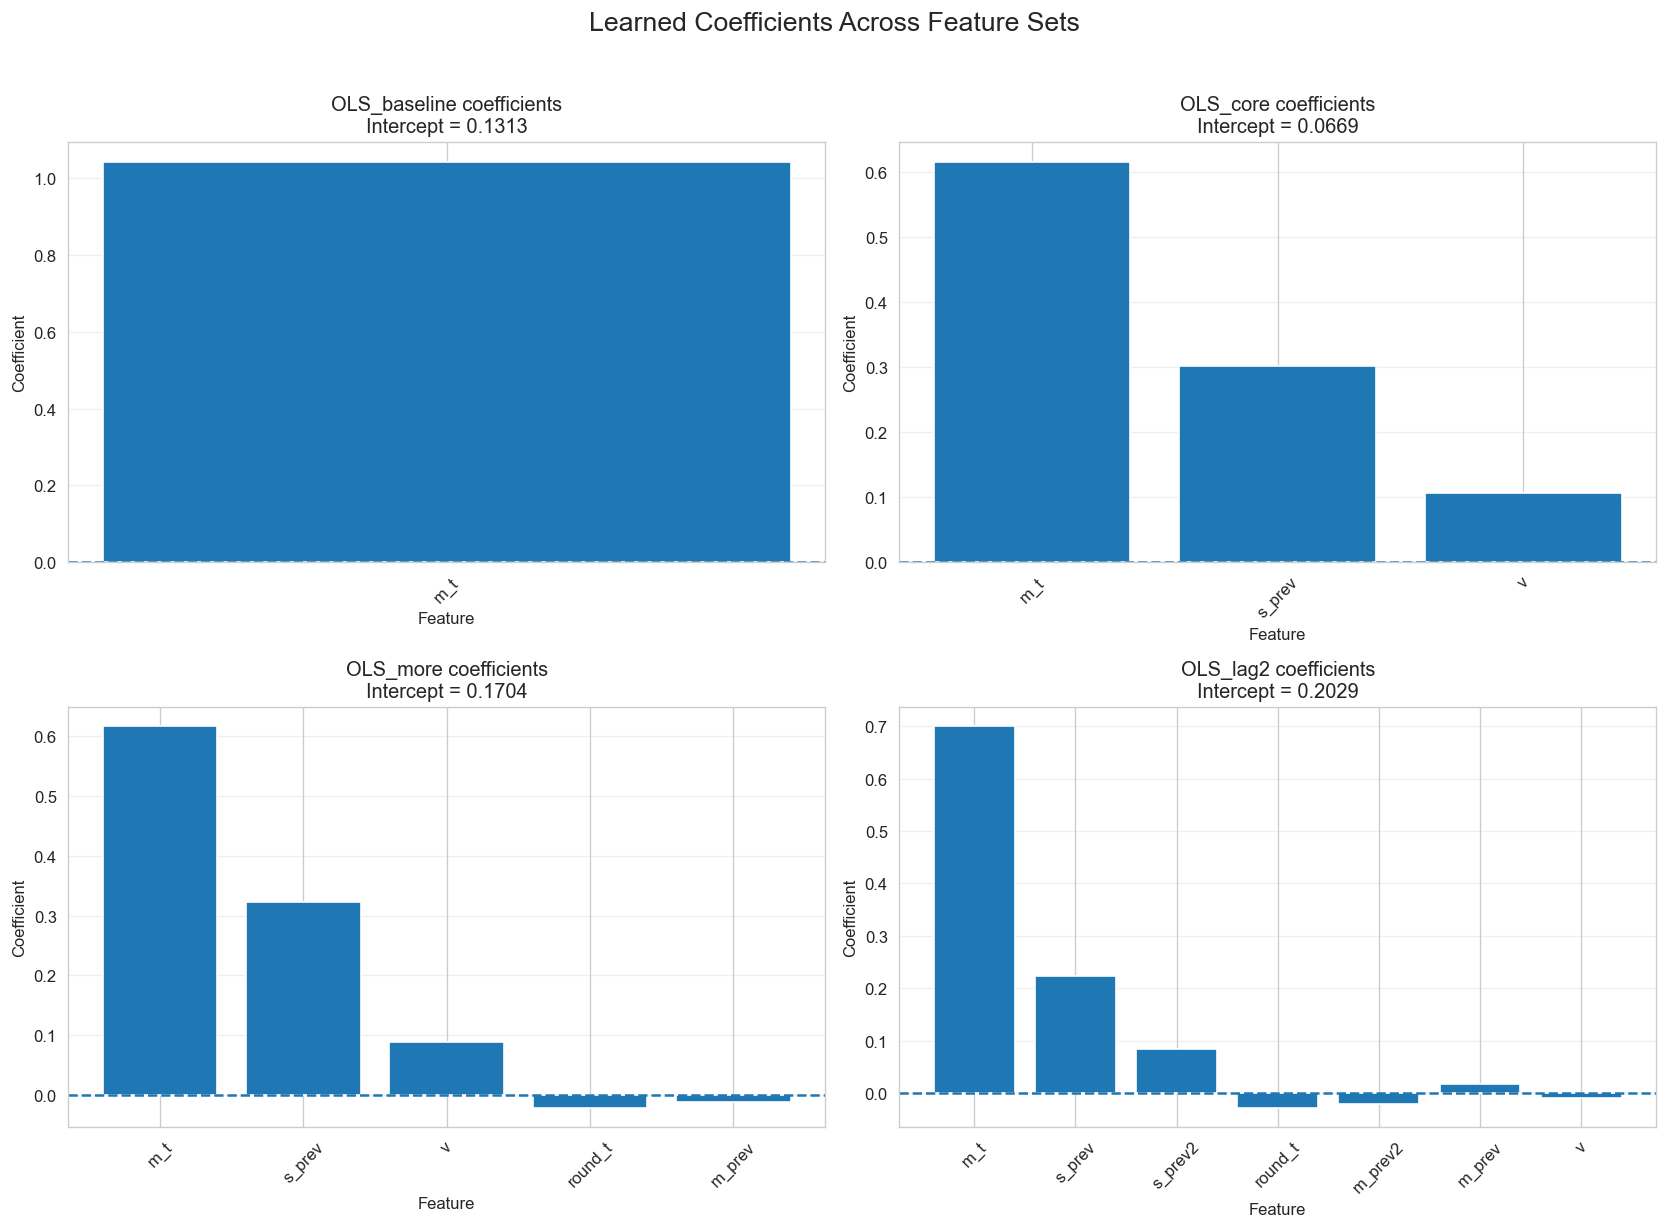

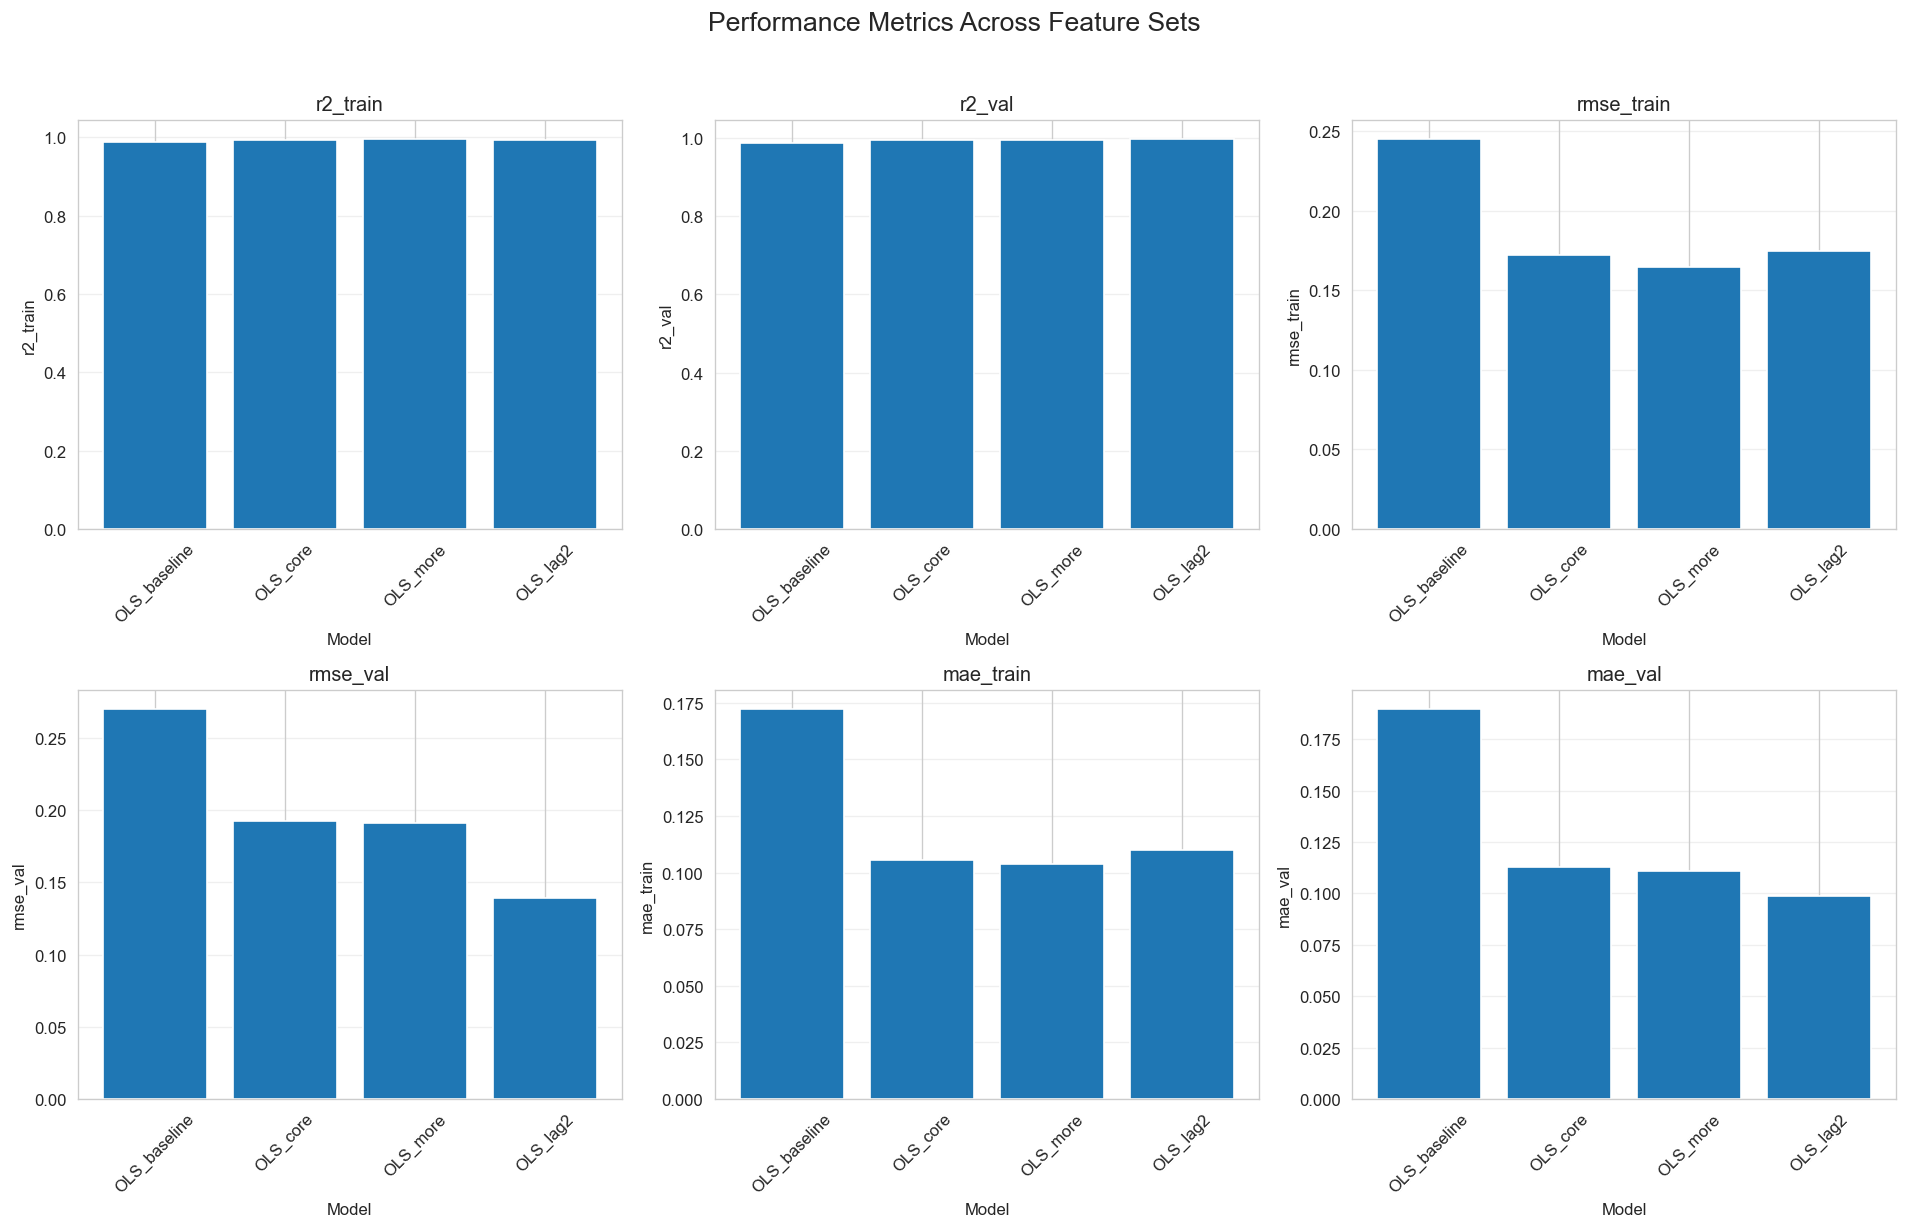


===== Best Validation Model by R^2 =====
model         OLS_lag2
dataset           lag2
n_features           7
r2_train      0.993413
r2_val         0.99522
rmse_train    0.174834
rmse_val      0.139238
mae_train     0.109837
mae_val       0.098662
Name: 3, dtype: object


In [13]:
# =========================================================
# 5. Large grid plot: predicted vs true
# =========================================================

n_models = len(all_results)
ncols = 2
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, r in zip(axes, all_results):
    y_val = r["y_val"]
    y_pred = r["y_pred_val"]

    ax.scatter(y_val, y_pred, alpha=0.5)
    lo = min(y_val.min(), y_pred.min())
    hi = max(y_val.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--')

    ax.set_xlabel("True s_t")
    ax.set_ylabel("Predicted s_t")
    ax.set_title(
        f"{r['model_name']}\n"
        f"R²(val)={r['r2_val']:.4f}, RMSE(val)={r['rmse_val']:.4f}"
    )
    ax.grid(alpha=0.3)

# hide unused axes
for j in range(len(all_results), len(axes)):
    axes[j].axis("off")

fig.suptitle("Validation Predictions: True vs Predicted", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# =========================================================
# 6. Large grid plot: residual histograms
# =========================================================

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, r in zip(axes, all_results):
    residuals = r["y_val"] - r["y_pred_val"]

    ax.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
    ax.set_xlabel("Residual = True - Predicted")
    ax.set_ylabel("Count")
    ax.set_title(
        f"{r['model_name']}\n"
        f"Mean residual={np.mean(residuals):.4f}, Std={np.std(residuals):.4f}"
    )
    ax.grid(alpha=0.3)

for j in range(len(all_results), len(axes)):
    axes[j].axis("off")

fig.suptitle("Validation Residual Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# =========================================================
# 7. Large grid plot: coefficient bars for each linear model
# =========================================================

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, r in zip(axes, all_results):
    coef_df = pd.DataFrame({
        "feature": r["feature_names"],
        "coefficient": r["coef"]
    }).sort_values("coefficient", key=lambda s: np.abs(s), ascending=False)

    ax.bar(coef_df["feature"], coef_df["coefficient"])
    ax.axhline(0, linestyle='--')
    ax.set_xlabel("Feature")
    ax.set_ylabel("Coefficient")
    ax.set_title(f"{r['model_name']} coefficients\nIntercept = {r['intercept']:.4f}")
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

for j in range(len(all_results), len(axes)):
    axes[j].axis("off")

fig.suptitle("Learned Coefficients Across Feature Sets", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# =========================================================
# 8. Large grid plot: metric comparison
# =========================================================

metric_names = ["r2_train", "r2_val", "rmse_train", "rmse_val", "mae_train", "mae_val"]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_df = results_table.copy()

for ax, metric in zip(axes, metric_names):
    ax.bar(plot_df["model"], plot_df[metric])
    ax.set_title(metric)
    ax.set_xlabel("Model")
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle("Performance Metrics Across Feature Sets", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# =========================================================
# 9. Best model by validation R^2
# =========================================================

best_idx = results_table["r2_val"].idxmax()
best_row = results_table.loc[best_idx]

print("\n===== Best Validation Model by R^2 =====")
print(best_row)

## If I use fraction, would performance be better?

In [14]:
baseline_features_frac = ['m_t']
core_features_frac = ['m_t', 's_prev']

more_features_frac = ['m_t', 's_prev', 'm_prev']
lag2_more_features = more_features + ['s_prev2', 'm_prev2']

# Core dataset (no missing)
df_target = df[(df['region'] == "Negotiation") & (df['round_t'] <= 8)].copy()

# ------ Baseline dataset ------
x_baseline = df_target[baseline_features].values.copy()
y_baseline = df_target['s_t'].values.copy()
v_baseline = df_target['v'].values.copy()
market_baseline = df_target['market'].values.copy()

# ------ Core dataset ------
x_core = df_target[core_features].values.copy()
y_core = df_target['s_t'].values.copy()
v_core = df_target['v'].values.copy()
market_core = df_target['market'].values.copy()

# ------ More features dataset ------
x_more = df_target[more_features].values.copy()
y_more = df_target['s_t'].values.copy()
v_more = df_target['v'].values.copy()
market_more = df_target['market'].values.copy()

# ------ Lag-2 dataset ------
df_lag2 = df_target.dropna(subset=['s_prev2', 'm_prev2']).copy()
x_lag2 = df_lag2[lag2_more_features].values.copy()
y_lag2 = df_lag2['s_t'].values.copy()
v_lag2 = df_lag2['v'].values.copy()
market_lag2 = df_lag2['market'].values.copy()


# =========================================================
# 1. Transformation helpers
# =========================================================

def to_fraction(X, y, v, market):
    """
    Transform covariates and response into fraction form:
        X_frac = (X - v) / (market - v)
        y_frac = (y - v) / (market - v)

    Here v and market are row-wise scalars, so broadcasting is used.
    """
    denom = market - v
    X_frac = (X - v.reshape(-1, 1)) / denom.reshape(-1, 1)
    y_frac = (y - v) / denom
    return X_frac, y_frac


def from_fraction(y_frac_pred, v, market):
    """
    Transform predicted fraction back to original scale:
        y_pred = v + (market - v) * y_frac_pred
    """
    return v + (market - v) * y_frac_pred


# =========================================================
# 2. Evaluation helper: fit in fraction space, evaluate in original space
# =========================================================

def evaluate_linear_model_fraction(
    X, y, v, market, feature_names, model_name,
    test_size=0.3, random_state=42
):
    """
    Fit OLS in fraction space, then convert predictions back to original scale
    for metric comparison.
    """

    X_train, X_val, y_train, y_val, v_train, v_val, market_train, market_val = train_test_split(
        X, y, v, market, test_size=test_size, random_state=random_state
    )

    # Transform to fraction space
    X_train_frac, y_train_frac = to_fraction(X_train, y_train, v_train, market_train)
    X_val_frac, y_val_frac = to_fraction(X_val, y_val, v_val, market_val)

    # Fit linear model in fraction space
    model = LinearRegression()
    model.fit(X_train_frac, y_train_frac)

    # Predict in fraction space
    y_pred_train_frac = model.predict(X_train_frac)
    y_pred_val_frac = model.predict(X_val_frac)

    # Convert predictions back to original scale
    y_pred_train = from_fraction(y_pred_train_frac, v_train, market_train)
    y_pred_val = from_fraction(y_pred_val_frac, v_val, market_val)

    result = {
        "model_name": model_name,
        "feature_names": feature_names,

        "X_train": X_train,
        "X_val": X_val,
        "X_train_frac": X_train_frac,
        "X_val_frac": X_val_frac,

        "y_train": y_train,
        "y_val": y_val,
        "y_train_frac": y_train_frac,
        "y_val_frac": y_val_frac,

        "y_pred_train_frac": y_pred_train_frac,
        "y_pred_val_frac": y_pred_val_frac,

        "y_pred_train": y_pred_train,
        "y_pred_val": y_pred_val,

        "v_train": v_train,
        "v_val": v_val,
        "market_train": market_train,
        "market_val": market_val,

        # Metrics computed in original scale
        "r2_train": r2_score(y_train, y_pred_train),
        "r2_val": r2_score(y_val, y_pred_val),
        "rmse_train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "rmse_val": np.sqrt(mean_squared_error(y_val, y_pred_val)),
        "mae_train": mean_absolute_error(y_train, y_pred_train),
        "mae_val": mean_absolute_error(y_val, y_pred_val),

        # Learned parameters in fraction space
        "intercept_frac": model.intercept_,
        "coef_frac": model.coef_,
        "model_obj": model,
    }

    return result


# =========================================================
# 3. Run experiments across feature sets
# =========================================================

datasets = {
    "baseline": (x_baseline, y_baseline, v_baseline, market_baseline, baseline_features),
    "core": (x_core, y_core, v_core, market_core, core_features),
    "more": (x_more, y_more, v_more, market_more, more_features),
    "lag2": (x_lag2, y_lag2, v_lag2, market_lag2, lag2_more_features),
}

all_results = []

for dataset_name, (X, y, v, market, feats) in datasets.items():
    result = evaluate_linear_model_fraction(
        X=X,
        y=y,
        v=v,
        market=market,
        feature_names=feats,
        model_name=f"OLS_frac_{dataset_name}",
        test_size=0.3,
        random_state=42
    )
    result["dataset_name"] = dataset_name
    all_results.append(result)


# =========================================================
# 4. Summary table
# =========================================================

results_table = pd.DataFrame([
    {
        "model": r["model_name"],
        "dataset": r["dataset_name"],
        "n_features": len(r["feature_names"]),
        "r2_train": r["r2_train"],
        "r2_val": r["r2_val"],
        "rmse_train": r["rmse_train"],
        "rmse_val": r["rmse_val"],
        "mae_train": r["mae_train"],
        "mae_val": r["mae_val"],
    }
    for r in all_results
])

print("\n===== Overall Results (trained in fraction space, evaluated in original scale) =====")
print(results_table.sort_values(by="r2_val", ascending=False).round(4))


# =========================================================
# 5. Learned parameter table (fraction space)
# =========================================================

param_rows = []
for r in all_results:
    param_rows.append({
        "model": r["model_name"],
        "feature": "INTERCEPT_FRAC",
        "coefficient": r["intercept_frac"]
    })
    for feat, coef in zip(r["feature_names"], r["coef_frac"]):
        param_rows.append({
            "model": r["model_name"],
            "feature": feat,
            "coefficient": coef
        })

linear_params_table = pd.DataFrame(param_rows)

print("\n===== Learned Parameters for Linear Models (fraction space) =====")
print(linear_params_table.round(6))







===== Overall Results (trained in fraction space, evaluated in original scale) =====
               model   dataset  n_features  r2_train  r2_val  rmse_train  \
3      OLS_frac_lag2      lag2           7    0.9921  0.9945      0.1912   
1      OLS_frac_core      core           3    0.9932  0.9921      0.1769   
2      OLS_frac_more      more           5    0.9933  0.9909      0.1758   
0  OLS_frac_baseline  baseline           1    0.9892  0.9881      0.2229   

   rmse_val  mae_train  mae_val  
3    0.1494     0.1076   0.1032  
1    0.2044     0.0972   0.1095  
2    0.2199     0.0967   0.1131  
0    0.2514     0.1598   0.1706  

===== Learned Parameters for Linear Models (fraction space) =====
                model         feature  coefficient
0   OLS_frac_baseline  INTERCEPT_FRAC     0.216714
1   OLS_frac_baseline             m_t     0.861920
2       OLS_frac_core  INTERCEPT_FRAC     0.064351
3       OLS_frac_core             m_t     0.573799
4       OLS_frac_core          s_prev    

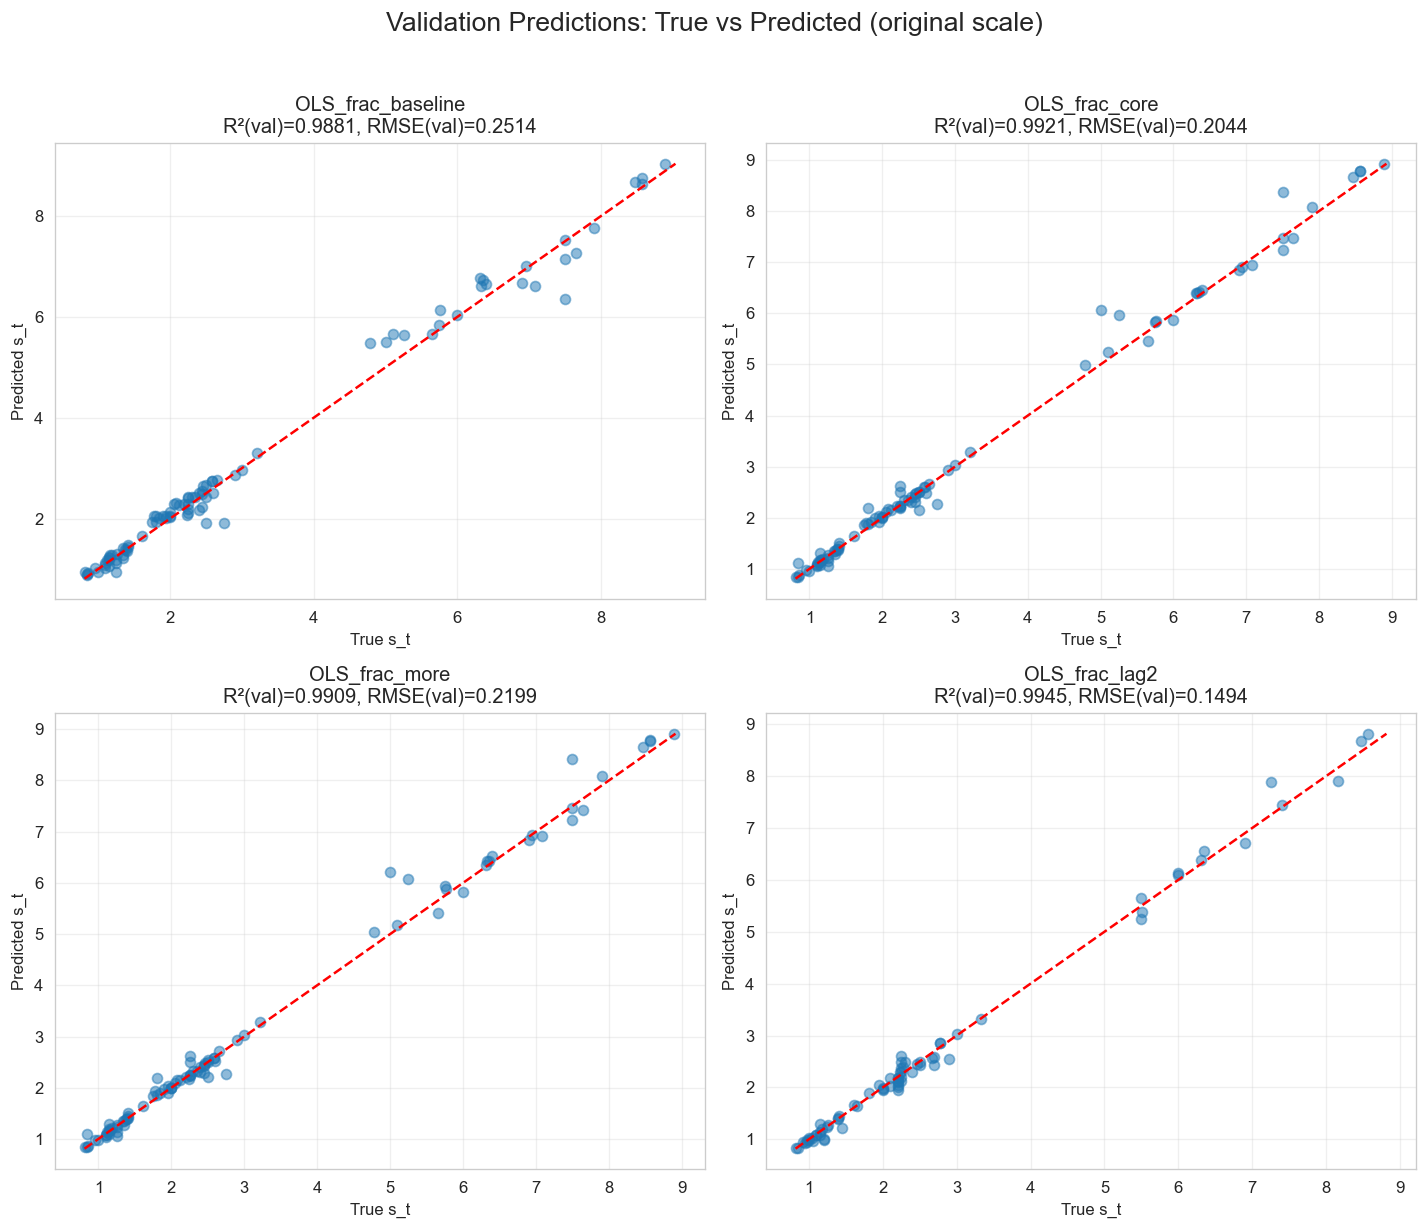

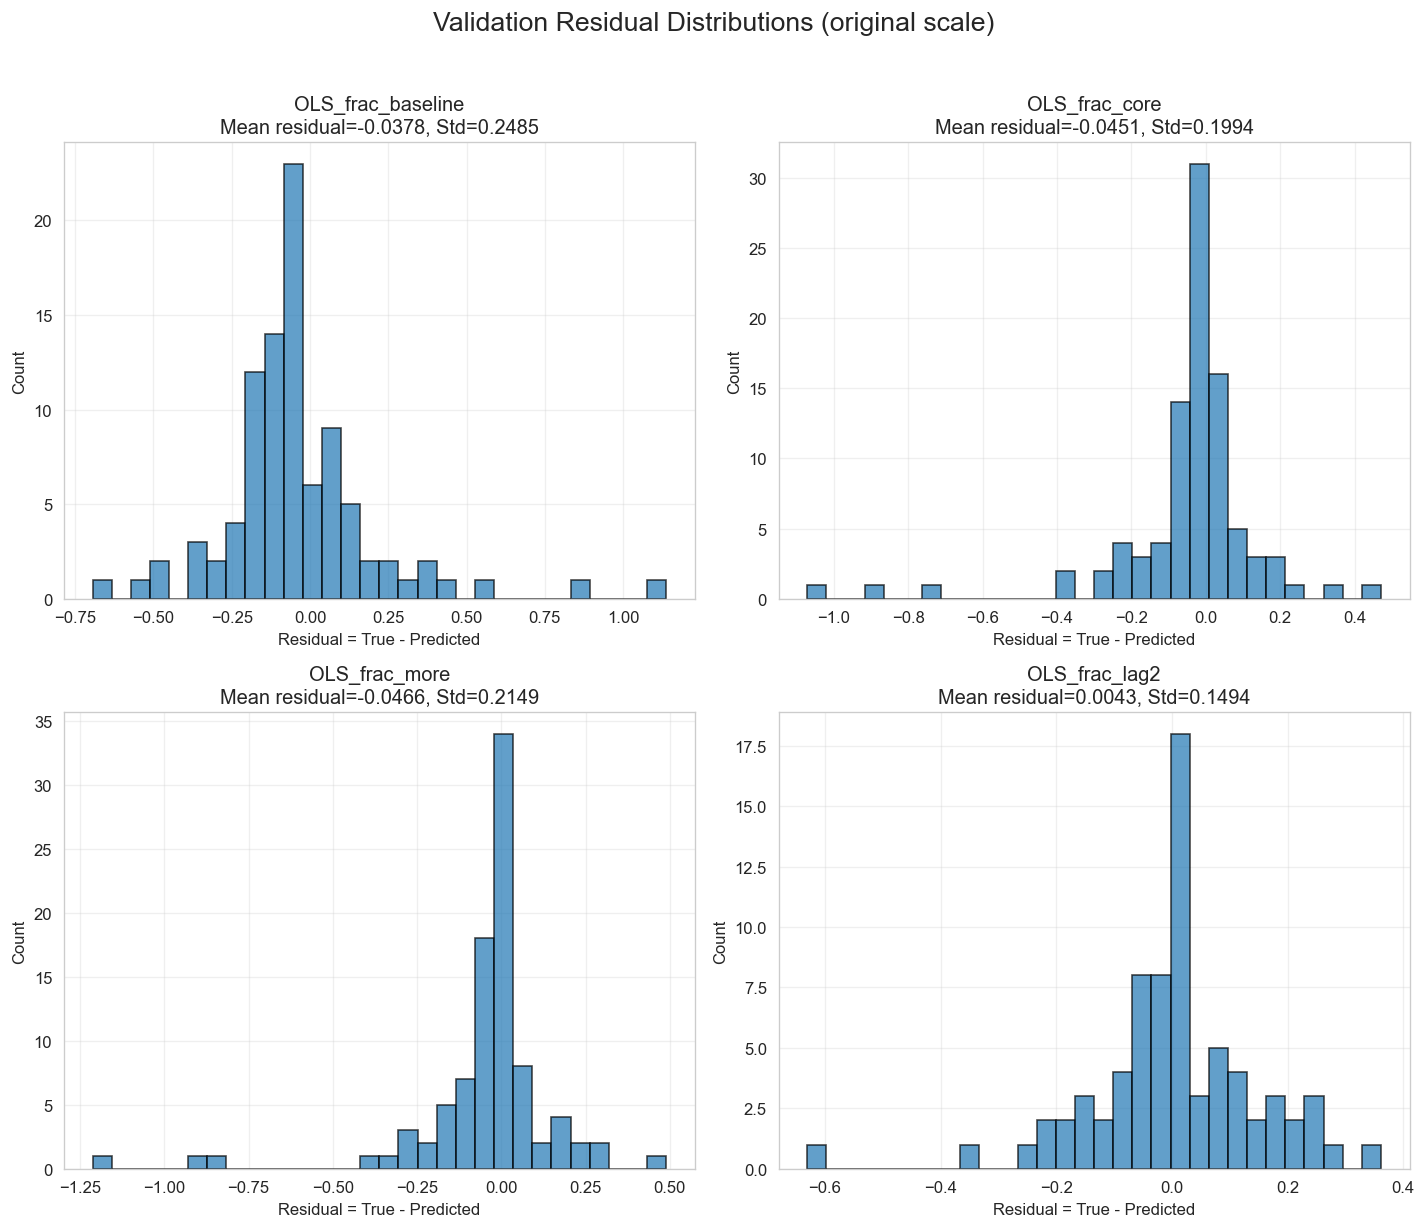

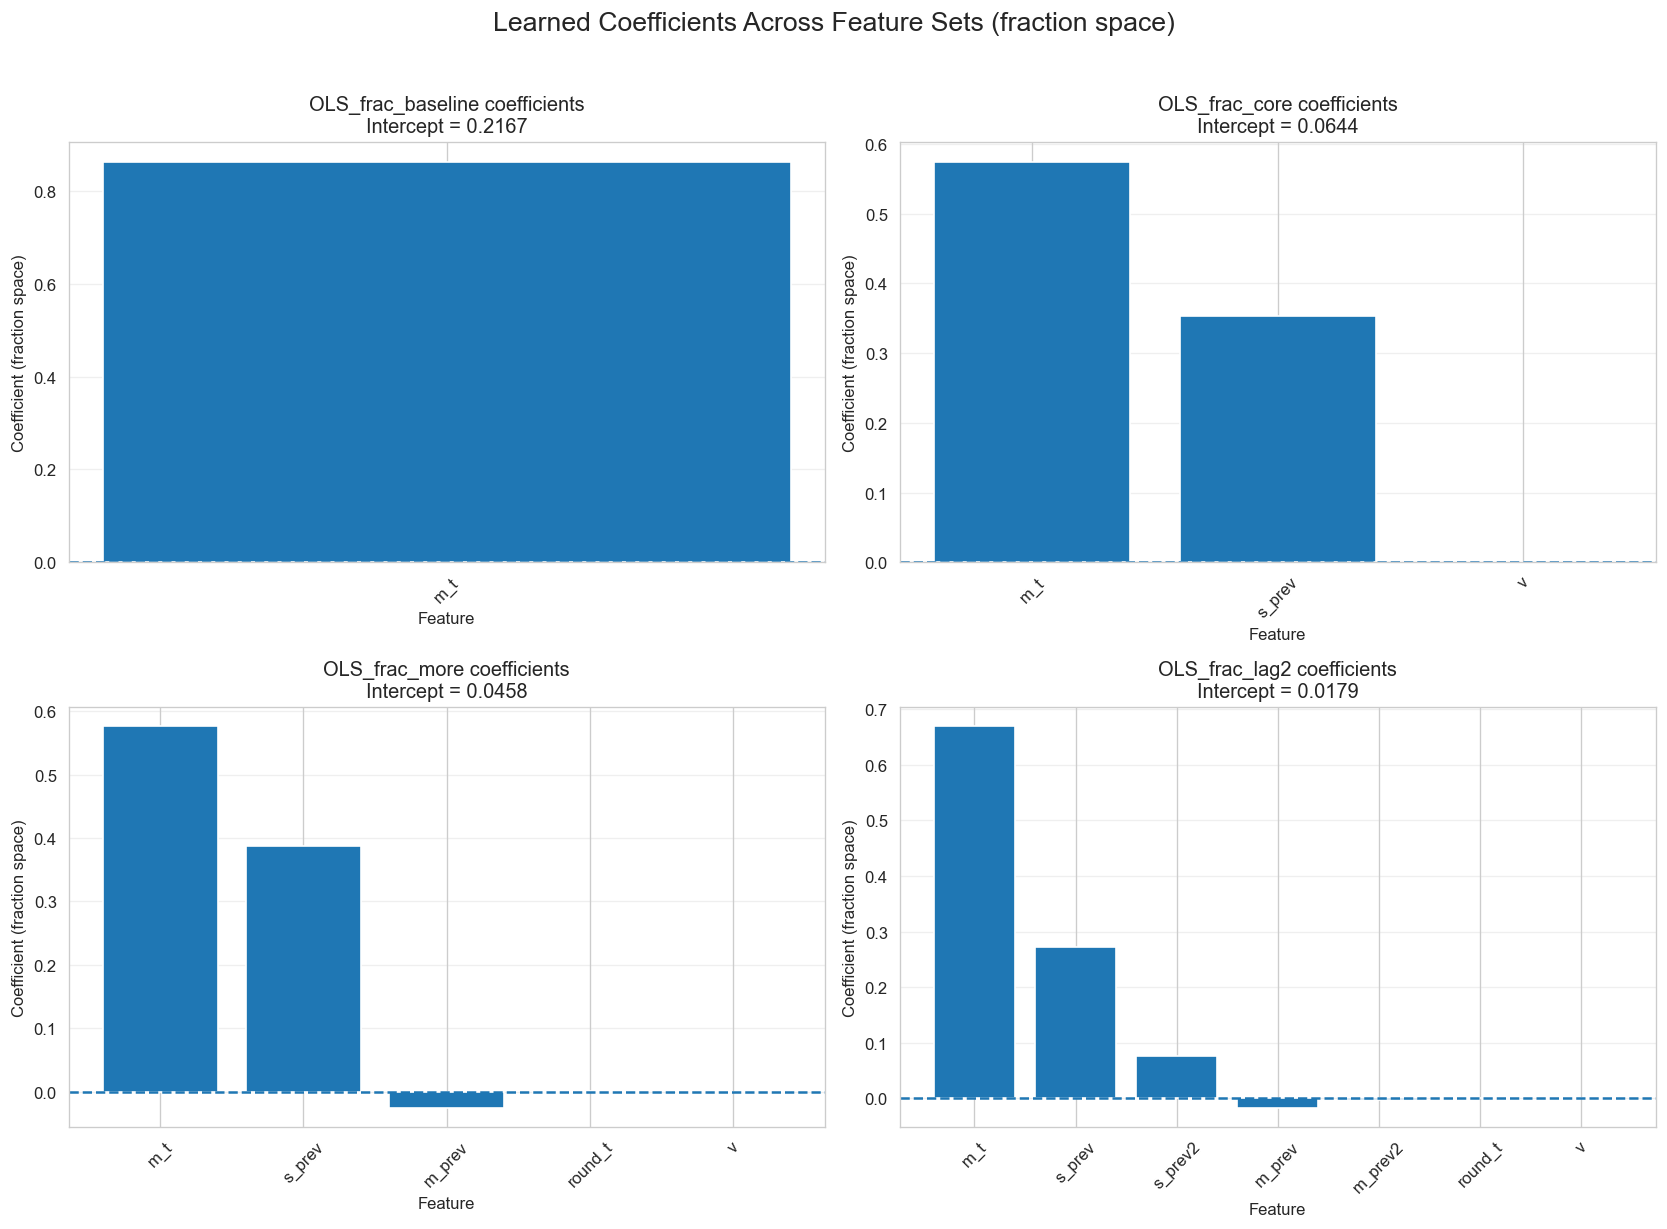

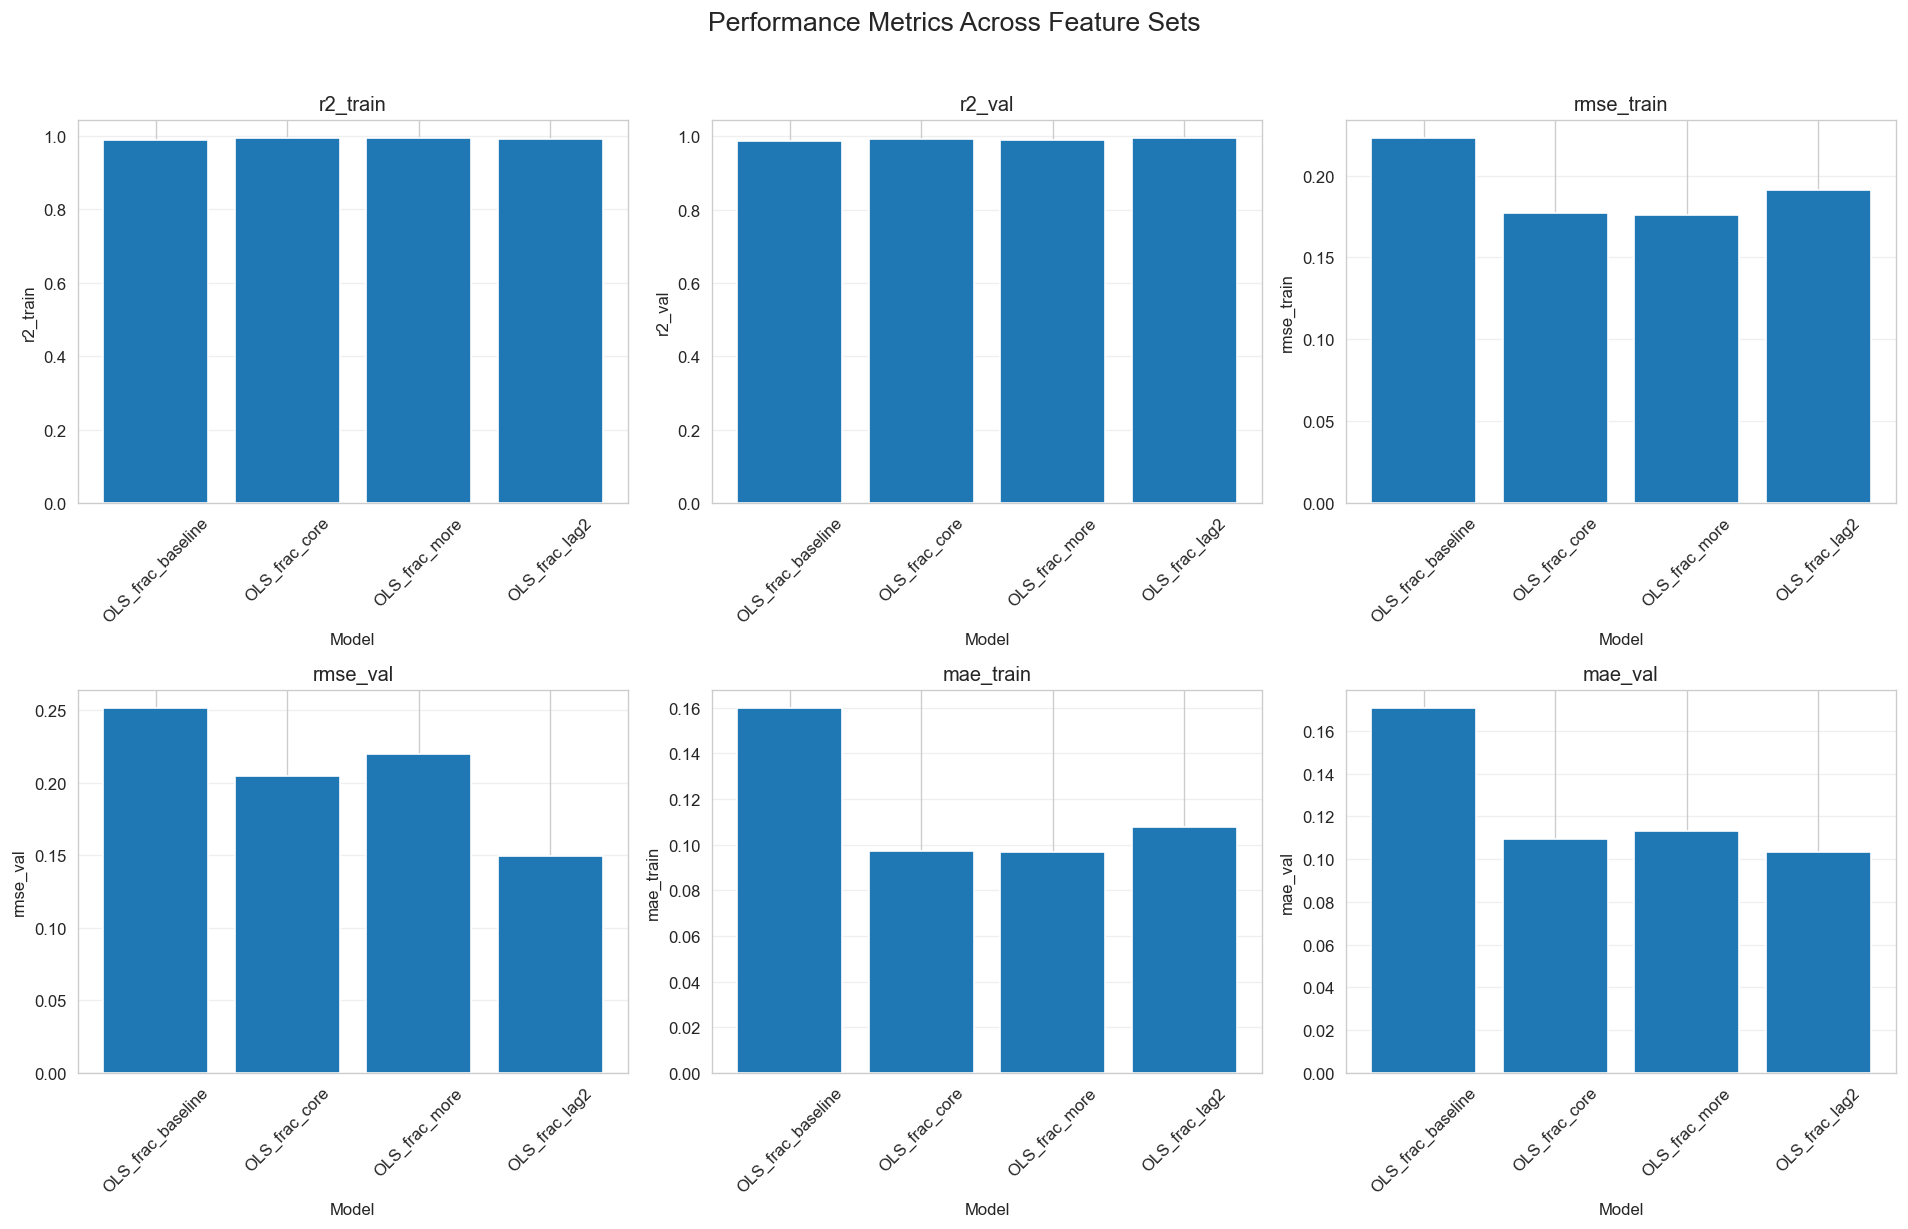


===== Best Validation Model by R^2 =====
model: OLS_frac_lag2
dataset: lag2
n_features: 7.0000
r2_train: 0.9921
r2_val: 0.9945
rmse_train: 0.1912
rmse_val: 0.1494
mae_train: 0.1076
mae_val: 0.1032


In [15]:
# =========================================================
# 6. Large grid plot: predicted vs true (original scale)
# =========================================================

n_models = len(all_results)
ncols = 2
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, r in zip(axes, all_results):
    y_val = r["y_val"]
    y_pred = r["y_pred_val"]

    ax.scatter(y_val, y_pred, alpha=0.5)
    lo = min(y_val.min(), y_pred.min())
    hi = max(y_val.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--')

    ax.set_xlabel("True s_t")
    ax.set_ylabel("Predicted s_t")
    ax.set_title(
        f"{r['model_name']}\n"
        f"R²(val)={r['r2_val']:.4f}, RMSE(val)={r['rmse_val']:.4f}"
    )
    ax.grid(alpha=0.3)

for j in range(len(all_results), len(axes)):
    axes[j].axis("off")

fig.suptitle("Validation Predictions: True vs Predicted (original scale)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# =========================================================
# 7. Large grid plot: residual histograms (original scale)
# =========================================================

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, r in zip(axes, all_results):
    residuals = r["y_val"] - r["y_pred_val"]

    ax.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
    ax.set_xlabel("Residual = True - Predicted")
    ax.set_ylabel("Count")
    ax.set_title(
        f"{r['model_name']}\n"
        f"Mean residual={np.mean(residuals):.4f}, Std={np.std(residuals):.4f}"
    )
    ax.grid(alpha=0.3)

for j in range(len(all_results), len(axes)):
    axes[j].axis("off")

fig.suptitle("Validation Residual Distributions (original scale)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# =========================================================
# 8. Large grid plot: coefficient bars (fraction space)
# =========================================================

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, r in zip(axes, all_results):
    coef_df = pd.DataFrame({
        "feature": r["feature_names"],
        "coefficient": r["coef_frac"]
    }).sort_values("coefficient", key=lambda s: np.abs(s), ascending=False)

    ax.bar(coef_df["feature"], coef_df["coefficient"])
    ax.axhline(0, linestyle='--')
    ax.set_xlabel("Feature")
    ax.set_ylabel("Coefficient (fraction space)")
    ax.set_title(f"{r['model_name']} coefficients\nIntercept = {r['intercept_frac']:.4f}")
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

for j in range(len(all_results), len(axes)):
    axes[j].axis("off")

fig.suptitle("Learned Coefficients Across Feature Sets (fraction space)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# =========================================================
# 9. Large grid plot: metric comparison
# =========================================================

metric_names = ["r2_train", "r2_val", "rmse_train", "rmse_val", "mae_train", "mae_val"]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_df = results_table.copy()

for ax, metric in zip(axes, metric_names):
    ax.bar(plot_df["model"], plot_df[metric])
    ax.set_title(metric)
    ax.set_xlabel("Model")
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle("Performance Metrics Across Feature Sets", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# =========================================================
# 10. Best model by validation R^2
# =========================================================

best_idx = results_table["r2_val"].idxmax()
best_row = results_table.loc[best_idx]

print("\n===== Best Validation Model by R^2 =====")
for col, val in best_row.items():
    if isinstance(val, (int, float, np.integer, np.floating)):
        print(f"{col}: {val:.4f}")
    else:
        print(f"{col}: {val}")

##  Quick conclusion

using fraction is not of much help. Including 2 step lags seem to help. The next step is to consider the low value zone